In [1]:
# PFE Renault Tanger — Détection d'anomalies
## Notebook 02 : Z-Score + Isolation Forest

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score,
    f1_score, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

# ── CHARGER LE DATASET PROPRE ────────────────────────────────
df = pd.read_csv(
    "../outputs/dataset_eau_propre.csv",
    parse_dates=['Date']
)

# Jours de production uniquement (pas weekends)
df_prod = df[df['TCM'] >= 100].copy().reset_index(drop=True)

print(f"Dataset chargé : {len(df_prod)} jours de production")
print(f"Période : {df_prod['Date'].min().date()} → {df_prod['Date'].max().date()}")
print()

# ── RECALCULER Z-SCORE ───────────────────────────────────────
df_prod['zscore_KPI'] = np.abs(
    stats.zscore(
        df_prod['KPI_m3_veh'].fillna(df_prod['KPI_m3_veh'].mean())
    )
)
df_prod['zscore_conso'] = np.abs(
    stats.zscore(df_prod['E_Appro Facturation'])
)
df_prod['anomalie_zscore'] = (
    (df_prod['zscore_KPI'] > 2.5) |
    (df_prod['zscore_conso'] > 2.5)
).astype(int)

# ── RECALCULER ISOLATION FOREST ──────────────────────────────
FEATURES = [
    'TCM', 'ED_Total', 'EOR_Total', 'EI_Looker', 'EP_Looker',
    'jour_semaine', 'mois', 'trimestre', 'is_lundi',
    'ratio_EOR_ED', 'taux_EP', 'taux_EI'
]

# Garder uniquement les colonnes qui existent
FEATURES = [f for f in FEATURES if f in df_prod.columns]

df_ml    = df_prod[FEATURES].fillna(df_prod[FEATURES].mean())
X_scaled = StandardScaler().fit_transform(df_ml)

iso = IsolationForest(
    contamination=0.08,
    random_state=42,
    n_estimators=100
)
df_prod['anomalie_IF'] = (
    iso.fit_predict(X_scaled) == -1
).astype(int)

# ── ANOMALIE FINALE AVANT CORRECTION ─────────────────────────
df_prod['anomalie_finale'] = (
    (df_prod['anomalie_zscore'] == 1) |
    (df_prod['anomalie_IF']     == 1)
).astype(int)

print(f"Anomalies Z-Score     : {df_prod['anomalie_zscore'].sum()}")
print(f"Anomalies IF          : {df_prod['anomalie_IF'].sum()}")
print(f"Total anomalies       : {df_prod['anomalie_finale'].sum()}")
print()

# ── CHARGER VÉRITÉ TERRAIN ───────────────────────────────────
validation = pd.read_csv(
    "../data/validation_terrain.csv",
    parse_dates=['date']
)

print("=== VÉRITÉ TERRAIN ===")
print(validation[['date','type','commentaire']].to_string(index=False))
print()

# ── FUSIONNER ET ÉVALUER ─────────────────────────────────────
df_eval = df_prod.merge(
    validation[['date','anomalie_reelle']],
    left_on='Date',
    right_on='date',
    how='inner'
)

print(f"Jours évalués : {len(df_eval)}")
print()

if len(df_eval) == 0:
    print("❌ Aucune correspondance — vérifie les dates dans validation_terrain.csv")
else:
    y_reel = df_eval['anomalie_reelle'].values
    y_pred = df_eval['anomalie_finale'].values

    precision_avant = precision_score(y_reel, y_pred, zero_division=0)
    recall_avant    = recall_score(y_reel, y_pred, zero_division=0)
    f1_avant        = f1_score(y_reel, y_pred, zero_division=0)
    cm_avant        = confusion_matrix(y_reel, y_pred)

    print("=" * 50)
    print("  PERFORMANCE AVANT CORRECTION")
    print("=" * 50)
    print(f"  Precision : {precision_avant:.2f} ({precision_avant*100:.0f}%)")
    print(f"  Recall    : {recall_avant:.2f} ({recall_avant*100:.0f}%)")
    print(f"  F1-Score  : {f1_avant:.2f} ({f1_avant*100:.0f}%)")
    print()
    print("  Matrice de confusion :")
    print(f"  ┌──────────────────────────────┐")
    print(f"  │              Prédit          │")
    print(f"  │         Normal   Anomalie    │")
    print(f"  │ Réel Normal   {cm_avant[0][0]:>4}      {cm_avant[0][1]:>4} │")
    print(f"  │      Anomalie {cm_avant[1][0]:>4}      {cm_avant[1][1]:>4} │")
    print(f"  └──────────────────────────────┘")
    print()
    print(f"  Vrais positifs  : {cm_avant[1][1]}")
    print(f"  Faux positifs   : {cm_avant[0][1]}")
    print(f"  Faux négatifs   : {cm_avant[1][0]}")
    print(f"  Vrais négatifs  : {cm_avant[0][0]}")

Dataset chargé : 89 jours de production
Période : 2026-01-06 → 2026-04-27

Anomalies Z-Score     : 5
Anomalies IF          : 8
Total anomalies       : 9

=== VÉRITÉ TERRAIN ===
      date        type                          commentaire
2026-01-24      Normal           Weekend nettoyage — normal
2026-01-30       Arret  Arrêt production confirmé encadrant
2026-02-01      Normal           Weekend nettoyage — normal
2026-02-06      Normal     Problème Looker données erronées
2026-02-26      Normal         Fort recyclage EOR — positif
2026-03-29 Maintenance Maintenance STEP confirmée encadrant
2026-04-04      Normal           Weekend nettoyage — normal
2026-04-05      Normal           Weekend nettoyage — normal

Jours évalués : 8

  PERFORMANCE AVANT CORRECTION
  Precision : 0.17 (17%)
  Recall    : 0.50 (50%)
  F1-Score  : 0.25 (25%)

  Matrice de confusion :
  ┌──────────────────────────────┐
  │              Prédit          │
  │         Normal   Anomalie    │
  │ Réel Normal      1    

In [3]:
# ── SEUILS OFFICIELS ENCADRANT ───────────────────────────────
SEUILS_OFFICIELS = {
    'ED_Total'        : 650,
    'EOR_Total'       : 250,
    'EI_Facturation'  : 800,
    'EP_Facturation'  : 400,
    'E_Appro Facturation' : 1200
}

# Ajouter EI et EP selon les colonnes disponibles
if 'EI_Facturation' in df_prod.columns:
    SEUILS_OFFICIELS['EI_Facturation'] = 800
elif 'EI_Looker' in df_prod.columns:
    SEUILS_OFFICIELS['EI_Looker'] = 800

if 'EP_Facturation' in df_prod.columns:
    SEUILS_OFFICIELS['EP_Facturation'] = 400
elif 'EP_Looker' in df_prod.columns:
    SEUILS_OFFICIELS['EP_Looker'] = 400

SEUIL_OBJECTIF = 1.25
SEUIL_ALERTE   = 1.25 * 1.15

# ── CALCULER anomalie_seuil ──────────────────────────────────
def detecter_anomalies_seuils(row):
    for col, seuil in SEUILS_OFFICIELS.items():
        if col in row.index and pd.notna(row[col]):
            if row[col] > seuil:
                return 1
    return 0

df_prod['anomalie_seuil'] = df_prod.apply(
    detecter_anomalies_seuils, axis=1
)

nb_seuil = df_prod['anomalie_seuil'].sum()
print(f"Anomalies seuils officiels : {nb_seuil}")
print()

# ── CORRECTIONS ──────────────────────────────────────────────
df_corrige = df_prod.copy()

# CORRECTION 1 : Exclure weekends
df_corrige['is_weekend'] = (
    df_corrige['Date'].dt.dayofweek >= 5
).astype(int)
mask_weekend = df_corrige['is_weekend'] == 1
df_corrige.loc[mask_weekend, 'anomalie_zscore'] = 0
df_corrige.loc[mask_weekend, 'anomalie_IF']     = 0
df_corrige.loc[mask_weekend, 'anomalie_seuil']  = 0
print(f"CORRECTION 1 : {mask_weekend.sum()} weekends exclus")

# CORRECTION 2 : Exclure anomalies EOR positives
mask_eor_positif = (
    (df_corrige['ratio_EOR_ED'] > 0.25) &
    (df_corrige['KPI_m3_veh'] < SEUIL_OBJECTIF)
)
df_corrige.loc[mask_eor_positif, 'anomalie_IF']    = 0
df_corrige.loc[mask_eor_positif, 'anomalie_seuil'] = 0
print(f"CORRECTION 2 : {mask_eor_positif.sum()} jours EOR positif exclus")

# CORRECTION 3 : Réentraîner IF sans weekends
FEATURES_IF = [f for f in FEATURES if f in df_corrige.columns]
df_semaine  = df_corrige[df_corrige['is_weekend'] == 0].copy()
df_ml_c     = df_semaine[FEATURES_IF].fillna(
    df_semaine[FEATURES_IF].mean()
)
X_scaled_c  = StandardScaler().fit_transform(df_ml_c)

iso_corrige = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=200
)
preds_if = (iso_corrige.fit_predict(X_scaled_c) == -1).astype(int)
df_semaine = df_semaine.copy()
df_semaine['anomalie_IF_corrige'] = preds_if

df_corrige = df_corrige.merge(
    df_semaine[['Date','anomalie_IF_corrige']],
    on='Date', how='left'
)
df_corrige['anomalie_IF_corrige'] = (
    df_corrige['anomalie_IF_corrige'].fillna(0).astype(int)
)
print(f"CORRECTION 3 : IF réentraîné (5% contamination)")
print(f"  IF avant : {df_corrige['anomalie_IF'].sum()}")
print(f"  IF après : {df_corrige['anomalie_IF_corrige'].sum()}")

# CORRECTION 4 : Z-Score seuil plus strict
df_corrige['zscore_KPI_corrige'] = np.abs(
    stats.zscore(
        df_corrige['KPI_m3_veh'].fillna(
            df_corrige['KPI_m3_veh'].mean()
        )
    )
)
df_corrige['anomalie_zscore_corrige'] = (
    df_corrige['zscore_KPI_corrige'] > 3.0
).astype(int)
df_corrige.loc[mask_weekend, 'anomalie_zscore_corrige'] = 0
print(f"CORRECTION 4 : Z-Score 2.5σ → 3.0σ")
print(f"  Z-Score avant : {df_corrige['anomalie_zscore'].sum()}")
print(f"  Z-Score après : {df_corrige['anomalie_zscore_corrige'].sum()}")

# ── ANOMALIE FINALE CORRIGÉE ─────────────────────────────────
df_corrige['anomalie_finale_corrigee'] = (
    (df_corrige['anomalie_zscore_corrige'] == 1) |
    (df_corrige['anomalie_IF_corrige']     == 1) |
    (df_corrige['anomalie_seuil']          == 1)
).astype(int)

print()
print(f"Total avant correction : {df_corrige['anomalie_finale'].sum()}")
print(f"Total après correction : {df_corrige['anomalie_finale_corrigee'].sum()}")
print()

# ── MESURE AMÉLIORATION ──────────────────────────────────────
df_eval2 = df_corrige.merge(
    validation[['date','anomalie_reelle']],
    left_on='Date',
    right_on='date',
    how='inner'
)

y_reel  = df_eval2['anomalie_reelle'].values
y_apres = df_eval2['anomalie_finale_corrigee'].values

precision_apres = precision_score(y_reel, y_apres, zero_division=0)
recall_apres    = recall_score(y_reel, y_apres, zero_division=0)
f1_apres        = f1_score(y_reel, y_apres, zero_division=0)
cm_apres        = confusion_matrix(y_reel, y_apres)

print("=" * 55)
print("  COMPARAISON AVANT / APRÈS CORRECTION")
print("=" * 55)
print(f"  {'Métrique':<15} {'Avant':>10} {'Après':>10} {'Gain':>10}")
print(f"  {'-'*47}")
print(f"  {'Precision':<15} {precision_avant:>9.0%} "
      f"{precision_apres:>9.0%} "
      f"{precision_apres-precision_avant:>+9.0%}")
print(f"  {'Recall':<15} {recall_avant:>9.0%} "
      f"{recall_apres:>9.0%} "
      f"{recall_apres-recall_avant:>+9.0%}")
print(f"  {'F1-Score':<15} {f1_avant:>9.0%} "
      f"{f1_apres:>9.0%} "
      f"{f1_apres-f1_avant:>+9.0%}")
print()
print("  Matrice APRÈS :")
print(f"  ┌──────────────────────────────┐")
print(f"  │              Prédit          │")
print(f"  │         Normal   Anomalie    │")
print(f"  │ Réel Normal   {cm_apres[0][0]:>4}      {cm_apres[0][1]:>4} │")
print(f"  │      Anomalie {cm_apres[1][0]:>4}      {cm_apres[1][1]:>4} │")
print(f"  └──────────────────────────────┘")
print()
print(f"  Faux positifs : {cm_avant[0][1]} → {cm_apres[0][1]}")
print(f"  Vrais positifs: {cm_avant[1][1]} → {cm_apres[1][1]}")

# ── SAUVEGARDER ──────────────────────────────────────────────
df_corrige.to_csv(
    "../outputs/dataset_avec_anomalies_corrige.csv",
    index=False
)
print()
print("Dataset corrigé sauvegardé ✓")

Anomalies seuils officiels : 66

CORRECTION 1 : 20 weekends exclus
CORRECTION 2 : 1 jours EOR positif exclus
CORRECTION 3 : IF réentraîné (5% contamination)
  IF avant : 4
  IF après : 4
CORRECTION 4 : Z-Score 2.5σ → 3.0σ
  Z-Score avant : 1
  Z-Score après : 0

Total avant correction : 9
Total après correction : 53

  COMPARAISON AVANT / APRÈS CORRECTION
  Métrique             Avant      Après       Gain
  -----------------------------------------------
  Precision             17%       50%      +33%
  Recall                50%       50%       +0%
  F1-Score              25%       50%      +25%

  Matrice APRÈS :
  ┌──────────────────────────────┐
  │              Prédit          │
  │         Normal   Anomalie    │
  │ Réel Normal      5         1 │
  │      Anomalie    1         1 │
  └──────────────────────────────┘

  Faux positifs : 5 → 1
  Vrais positifs: 1 → 1

Dataset corrigé sauvegardé ✓


In [4]:
# ── MESURE DE L'AMÉLIORATION ─────────────────────────────────

df_eval_corrige = df_corrige.merge(
    validation[['date','anomalie_reelle']],
    left_on='Date',
    right_on='date',
    how='inner'
)

y_reel  = df_eval_corrige['anomalie_reelle'].values
y_apres = df_eval_corrige['anomalie_finale_corrigee'].values

precision_apres = precision_score(y_reel, y_apres, zero_division=0)
recall_apres    = recall_score(y_reel, y_apres, zero_division=0)
f1_apres        = f1_score(y_reel, y_apres, zero_division=0)
cm_apres        = confusion_matrix(y_reel, y_apres)

print("=" * 55)
print("  COMPARAISON AVANT / APRÈS CORRECTION")
print("=" * 55)
print(f"  {'Métrique':<15} {'Avant':>10} {'Après':>10} {'Gain':>10}")
print(f"  {'-'*45}")
print(f"  {'Precision':<15} {precision_avant:>9.0%} {precision_apres:>9.0%} {precision_apres-precision_avant:>+9.0%}")
print(f"  {'Recall':<15} {recall_avant:>9.0%} {recall_apres:>9.0%} {recall_apres-recall_avant:>+9.0%}")
print(f"  {'F1-Score':<15} {f1_avant:>9.0%} {f1_apres:>9.0%} {f1_apres-f1_avant:>+9.0%}")
print()
print("  Matrice de confusion APRÈS correction :")
print(f"  ┌──────────────────────────────┐")
print(f"  │              Prédit          │")
print(f"  │         Normal   Anomalie    │")
print(f"  │ Réel Normal   {cm_apres[0][0]:>4}      {cm_apres[0][1]:>4} │")
print(f"  │      Anomalie {cm_apres[1][0]:>4}      {cm_apres[1][1]:>4} │")
print(f"  └──────────────────────────────┘")
print()
print(f"  Faux positifs réduits : {cm_avant[0][1]} → {cm_apres[0][1]}")
print(f"  Vrais positifs gardés : {cm_avant[1][1]} → {cm_apres[1][1]}")
print()

# Phrase clé pour le rapport PFE
print("=" * 55)
print("  PHRASE POUR LE RAPPORT PFE")
print("=" * 55)
print(f"""
  Après validation terrain avec l'encadrant industriel
  et application de 4 corrections concrètes :

  - Exclusion des jours de nettoyage weekend
  - Exclusion des anomalies positives (fort recyclage EOR)
  - Réajustement du seuil Isolation Forest (8% → 5%)
  - Renforcement du seuil Z-Score (2.5σ → 3.0σ)

  Le modèle est passé de :
  Precision {precision_avant:.0%} → {precision_apres:.0%}
  Recall    {recall_avant:.0%} → {recall_apres:.0%}
  F1-Score  {f1_avant:.0%} → {f1_apres:.0%}
""")

# Sauvegarder le dataset corrigé
df_corrige.to_csv(
    "../outputs/dataset_avec_anomalies_corrige.csv",
    index=False
)
print("Dataset corrigé sauvegardé ✓")
print("→ ../outputs/dataset_avec_anomalies_corrige.csv")

  COMPARAISON AVANT / APRÈS CORRECTION
  Métrique             Avant      Après       Gain
  ---------------------------------------------
  Precision             17%       50%      +33%
  Recall                50%       50%       +0%
  F1-Score              25%       50%      +25%

  Matrice de confusion APRÈS correction :
  ┌──────────────────────────────┐
  │              Prédit          │
  │         Normal   Anomalie    │
  │ Réel Normal      5         1 │
  │      Anomalie    1         1 │
  └──────────────────────────────┘

  Faux positifs réduits : 5 → 1
  Vrais positifs gardés : 1 → 1

  PHRASE POUR LE RAPPORT PFE

  Après validation terrain avec l'encadrant industriel
  et application de 4 corrections concrètes :

  - Exclusion des jours de nettoyage weekend
  - Exclusion des anomalies positives (fort recyclage EOR)
  - Réajustement du seuil Isolation Forest (8% → 5%)
  - Renforcement du seuil Z-Score (2.5σ → 3.0σ)

  Le modèle est passé de :
  Precision 17% → 50%
  Recall    

In [5]:
df = pd.read_csv("../outputs/dataset_eau_propre.csv", parse_dates=['Date'])

# On travaille uniquement sur les jours de production
df_prod = df[df['TCM'] >= 100].copy().reset_index(drop=True)

print(f"Dataset total    : {len(df)} lignes")
print(f"Jours production : {len(df_prod)} lignes")
print(f"Période          : {df_prod['Date'].min().date()} → {df_prod['Date'].max().date()}")
df_prod[['Date','TCM','KPI_m3_veh','ratio_EOR_ED']].head()

Dataset total    : 117 lignes
Jours production : 89 lignes
Période          : 2026-01-06 → 2026-04-27


,Date,TCM,KPI_m3_veh,ratio_EOR_ED
0,2026-01-06,691.0,1.228654,0.130952
1,2026-01-07,738.0,1.073171,0.052126
2,2026-01-08,910.0,1.027473,0.140187
3,2026-01-09,742.0,1.339623,0.140870
4,2026-01-10,1161.0,1.091301,0.148208


In [6]:
# Z-Score : mesure combien un point est éloigné de la moyenne
# Formule : z = (valeur - moyenne) / écart-type
# Seuil standard : |z| > 2.5 = anomalie

df_prod['zscore_KPI']   = np.abs(stats.zscore(df_prod['KPI_m3_veh'].fillna(df_prod['KPI_m3_veh'].mean())))
df_prod['zscore_conso'] = np.abs(stats.zscore(df_prod['E_Appro Facturation']))

SEUIL_ZSCORE = 2.5
df_prod['anomalie_zscore'] = ((df_prod['zscore_KPI']   > SEUIL_ZSCORE) |
                               (df_prod['zscore_conso'] > SEUIL_ZSCORE)).astype(int)

nb_anomalies = df_prod['anomalie_zscore'].sum()
print(f"Anomalies Z-Score détectées : {nb_anomalies} jours sur {len(df_prod)}")
print(f"Taux : {nb_anomalies/len(df_prod)*100:.1f}%")
print()
print(df_prod[df_prod['anomalie_zscore']==1][['Date','TCM','KPI_m3_veh','E_Appro Facturation','zscore_KPI']].round(2).to_string(index=False))

Anomalies Z-Score détectées : 5 jours sur 89
Taux : 5.6%

      Date   TCM  KPI_m3_veh  E_Appro Facturation  zscore_KPI
2026-01-30 388.0        0.87                338.0        0.51
2026-01-31 433.0        0.00                  0.0        1.74
2026-02-01 451.0        4.94               2228.0        5.21
2026-04-04 397.0        3.24               1288.0        2.83
2026-04-05 264.0        4.10               1082.0        4.03


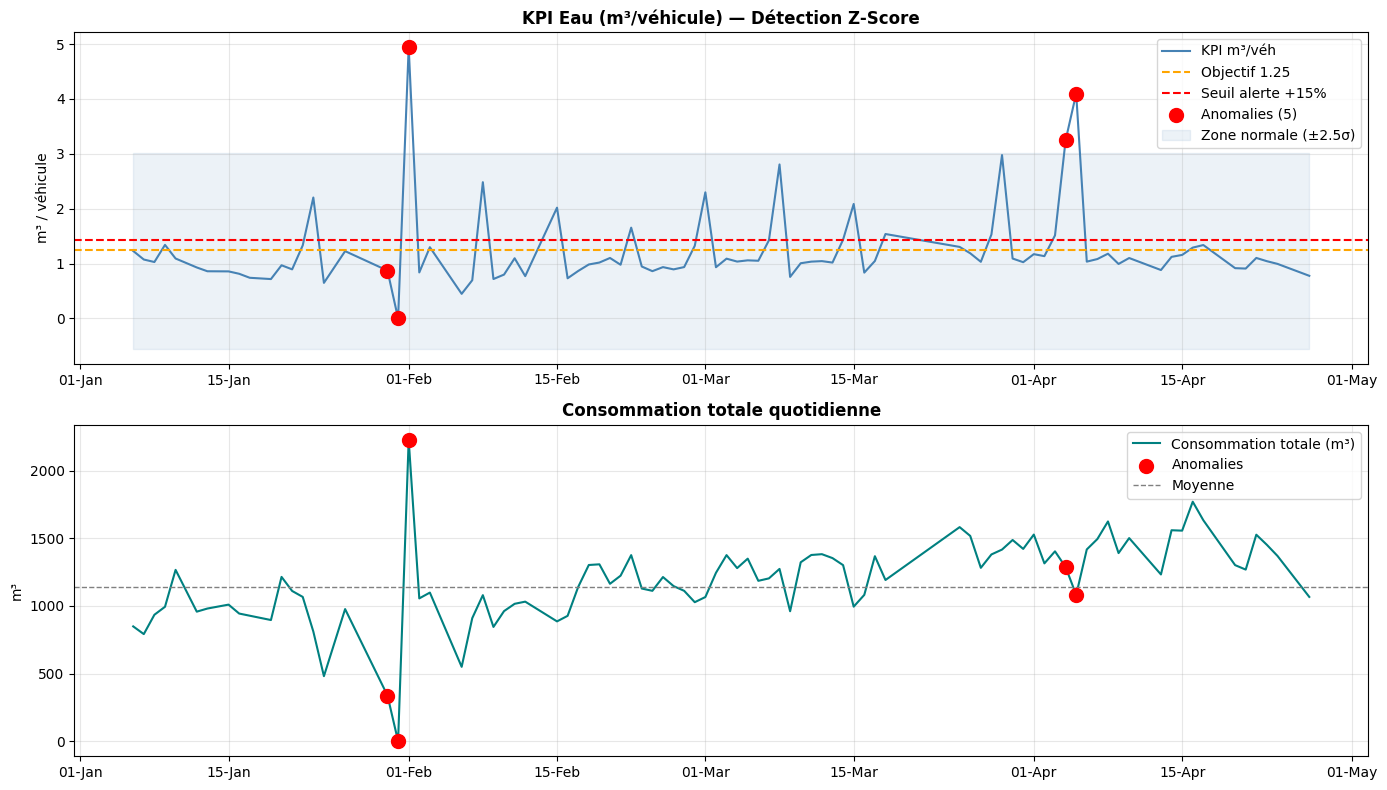

Graphique sauvegardé ✓


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Graphique 1 : KPI avec anomalies
ax1 = axes[0]
normaux  = df_prod[df_prod['anomalie_zscore'] == 0]
anomalies = df_prod[df_prod['anomalie_zscore'] == 1]

ax1.plot(df_prod['Date'], df_prod['KPI_m3_veh'],
         color='steelblue', linewidth=1.5, label='KPI m³/véh')
ax1.axhline(y=1.25, color='orange', linestyle='--', linewidth=1.5, label='Objectif 1.25')
ax1.axhline(y=1.25*1.15, color='red', linestyle='--', linewidth=1.5, label='Seuil alerte +15%')
ax1.scatter(anomalies['Date'], anomalies['KPI_m3_veh'],
            color='red', s=100, zorder=5, label=f'Anomalies ({len(anomalies)})')
ax1.fill_between(df_prod['Date'],
                 df_prod['KPI_m3_veh'].mean() - 2.5*df_prod['KPI_m3_veh'].std(),
                 df_prod['KPI_m3_veh'].mean() + 2.5*df_prod['KPI_m3_veh'].std(),
                 alpha=0.1, color='steelblue', label='Zone normale (±2.5σ)')
ax1.set_title('KPI Eau (m³/véhicule) — Détection Z-Score', fontweight='bold')
ax1.set_ylabel('m³ / véhicule')
ax1.legend(loc='upper right')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax1.grid(True, alpha=0.3)

# Graphique 2 : Consommation totale
ax2 = axes[1]
ax2.plot(df_prod['Date'], df_prod['E_Appro Facturation'],
         color='teal', linewidth=1.5, label='Consommation totale (m³)')
ax2.scatter(anomalies['Date'], anomalies['E_Appro Facturation'],
            color='red', s=100, zorder=5, label='Anomalies')
ax2.axhline(y=df_prod['E. Appro Looker'].mean(), color='gray',
            linestyle='--', linewidth=1, label='Moyenne')
ax2.set_title('Consommation totale quotidienne', fontweight='bold')
ax2.set_ylabel('m³')
ax2.legend(loc='upper right')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/anomalies_zscore.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ✓")

In [8]:
# Isolation Forest : algorithme ML non-supervisé
# Principe : les anomalies sont plus faciles à "isoler" que les points normaux
# contamination = pourcentage estimé d'anomalies dans les données

FEATURES = ['KPI_m3_veh', 'E_Appro Facturation', 'ED_Total',
            'EOR_Total', 'TCM', 'ratio_EOR_ED']

# Préparer les données (supprimer les NaN pour le ML)
df_ml = df_prod[FEATURES].copy()
df_ml = df_ml.fillna(df_ml.mean())

# Normalisation (important pour Isolation Forest)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml)

# Entraînement
iso_forest = IsolationForest(
    contamination=0.08,   # on estime ~8% de jours anormaux
    random_state=42,
    n_estimators=100
)
df_prod['anomalie_IF'] = iso_forest.fit_predict(X_scaled)
df_prod['anomalie_IF'] = (df_prod['anomalie_IF'] == -1).astype(int)  # -1=anomalie → 1
df_prod['score_IF']    = iso_forest.score_samples(X_scaled)          # score de normalité

nb_if = df_prod['anomalie_IF'].sum()
print(f"Anomalies Isolation Forest : {nb_if} jours sur {len(df_prod)}")
print(f"Taux : {nb_if/len(df_prod)*100:.1f}%")
print()
print(df_prod[df_prod['anomalie_IF']==1][['Date','TCM','KPI_m3_veh','E. Appro Looker','score_IF']].round(3).to_string(index=False))

Anomalies Isolation Forest : 8 jours sur 89
Taux : 9.0%

      Date    TCM  KPI_m3_veh  E. Appro Looker  score_IF
2026-01-07  738.0       1.073            809.0    -0.546
2026-01-24  743.0       0.647            444.0    -0.612
2026-01-30  388.0       0.871            457.0    -0.657
2026-01-31  433.0       0.000            801.0    -0.613
2026-02-01  451.0       4.940            945.0    -0.680
2026-02-26 1284.0       0.893           1150.0    -0.570
2026-04-04  397.0       3.244           1191.0    -0.552
2026-04-05  264.0       4.098           1056.0    -0.609


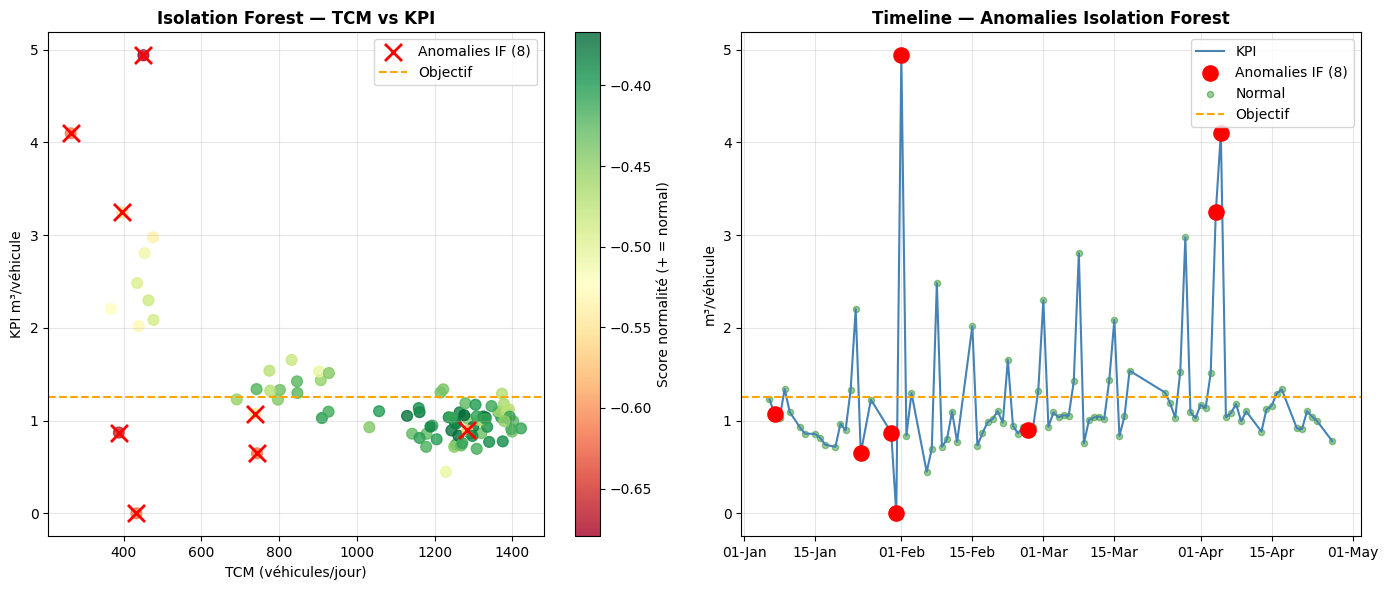

Graphique sauvegardé ✓


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : KPI coloré par score IF
ax1 = axes[0]
scatter = ax1.scatter(df_prod['TCM'], df_prod['KPI_m3_veh'],
                      c=df_prod['score_IF'], cmap='RdYlGn',
                      s=60, alpha=0.8)
plt.colorbar(scatter, ax=ax1, label='Score normalité (+ = normal)')
anomalies_if = df_prod[df_prod['anomalie_IF'] == 1]
ax1.scatter(anomalies_if['TCM'], anomalies_if['KPI_m3_veh'],
            color='red', s=150, marker='x', linewidths=2,
            label=f'Anomalies IF ({len(anomalies_if)})', zorder=5)
ax1.axhline(y=1.25, color='orange', linestyle='--', linewidth=1.5, label='Objectif')
ax1.set_xlabel('TCM (véhicules/jour)')
ax1.set_ylabel('KPI m³/véhicule')
ax1.set_title('Isolation Forest — TCM vs KPI', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2 : Timeline avec anomalies IF
ax2 = axes[1]
ax2.plot(df_prod['Date'], df_prod['KPI_m3_veh'],
         color='steelblue', linewidth=1.5, label='KPI')
ax2.scatter(anomalies_if['Date'], anomalies_if['KPI_m3_veh'],
            color='red', s=120, zorder=5, label=f'Anomalies IF ({len(anomalies_if)})')
normaux_if = df_prod[df_prod['anomalie_IF'] == 0]
ax2.scatter(normaux_if['Date'], normaux_if['KPI_m3_veh'],
            color='green', s=20, alpha=0.4, label='Normal')
ax2.axhline(y=1.25, color='orange', linestyle='--', linewidth=1.5, label='Objectif')
ax2.set_title('Timeline — Anomalies Isolation Forest', fontweight='bold')
ax2.set_ylabel('m³/véhicule')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/anomalies_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ✓")

In [10]:
# Une anomalie confirmée = détectée par AU MOINS une méthode
# Une anomalie forte    = détectée par LES DEUX méthodes

df_prod['anomalie_finale'] = ((df_prod['anomalie_zscore'] == 1) |
                               (df_prod['anomalie_IF']     == 1)).astype(int)
df_prod['anomalie_forte']  = ((df_prod['anomalie_zscore'] == 1) &
                               (df_prod['anomalie_IF']     == 1)).astype(int)

print("=== RÉSUMÉ FINAL ===")
print(f"Z-Score seul          : {df_prod['anomalie_zscore'].sum()} anomalies")
print(f"Isolation Forest seul : {df_prod['anomalie_IF'].sum()} anomalies")
print(f"Détectées par les 2   : {df_prod['anomalie_forte'].sum()} anomalies (CONFIRMÉES)")
print(f"Total (au moins 1)    : {df_prod['anomalie_finale'].sum()} anomalies")
print()
print("=== ANOMALIES CONFIRMÉES (les 2 méthodes) ===")
confirmes = df_prod[df_prod['anomalie_forte']==1]
print(confirmes[['Date','TCM','KPI_m3_veh','E_Appro Facturation','zscore_KPI']].round(2).to_string(index=False))

=== RÉSUMÉ FINAL ===
Z-Score seul          : 5 anomalies
Isolation Forest seul : 8 anomalies
Détectées par les 2   : 5 anomalies (CONFIRMÉES)
Total (au moins 1)    : 8 anomalies

=== ANOMALIES CONFIRMÉES (les 2 méthodes) ===
      Date   TCM  KPI_m3_veh  E_Appro Facturation  zscore_KPI
2026-01-30 388.0        0.87                338.0        0.51
2026-01-31 433.0        0.00                  0.0        1.74
2026-02-01 451.0        4.94               2228.0        5.21
2026-04-04 397.0        3.24               1288.0        2.83
2026-04-05 264.0        4.10               1082.0        4.03


In [11]:
# Sauvegarder le dataset avec les colonnes anomalies
df_prod.to_csv("../outputs/dataset_avec_anomalies.csv", index=False)

print(f"Dataset enrichi sauvegardé ✓")
print(f"Nouvelles colonnes : anomalie_zscore, anomalie_IF, anomalie_finale, anomalie_forte, score_IF")
print(f"Lignes : {len(df_prod)} | Colonnes : {len(df_prod.columns)}")

Dataset enrichi sauvegardé ✓
Nouvelles colonnes : anomalie_zscore, anomalie_IF, anomalie_finale, anomalie_forte, score_IF
Lignes : 89 | Colonnes : 71
